# Feature Importance Analysis

In this notebook we perform feature analysis on the weighted Random Forest Classifer model across our 3 datasets from the previous experiment due to its ability to capture non-linear relationships and provide stable, interpretable importance scores.

In [ ]:
#Installing all require libraries
%pip install pandas
%pip install seaborn
%pip install matplotlib
%pip install joblib

In [2]:
#All imports needed for this experiment

import pandas as pd
import joblib

import seaborn as sns
import matplotlib.pyplot as plt


## Helper Functions

In [3]:
feature_name_map = {
    'bp':   'Blood pressure (mm/Hg)',
    'sg':   'Specific gravity of urine',
    'al':   'Albumin in urine',
    'su':   'Sugar in urine',
    'bu':   'Blood urea (mg/dl)',
    'sc':   'Serum creatinine (mg/dl)',
    'sod':  'Sodium level (mEq/L)',
    'pot':  'Potassium level (mEq/L)',
    'hemo': 'Hemoglobin level (gms)',
    'rbc':  'Red blood cell count (millions/cumm)',
    'wc':   'White blood cell count (cells/cumm)',
    'rc':   'Red blood cell count (millions/cumm)',
    'htn':  'Hypertension (yes/no)'
}

In [4]:
def plot_encoded_feature_importance(model, feature_names, title, top_n=15):

    #Get feature importances from model
    importances = model.feature_importances_
    
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).head(top_n)
    
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.barplot(
        data=feature_importance_df,
        x='importance',
        y='feature',
        hue='feature',
        palette='RdYlGn_r',
        legend=False,
        ax=ax
    )
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Feature Importance')
    ax.set_ylabel('Feature')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'Top {top_n} Most Important Features:')
    print('=' * 45)

    rank = 1
    for index, row in feature_importance_df.iterrows():
        print(f'{rank:>2}. {row['feature']:<10s} {row['importance']:.4f}')
        rank +=1

In [5]:
def plot_original_feature_importance(model, numeric_features, title):
    original_importances = {}
    # importances = np.abs(model.coef_[0])
    importances = model.feature_importances_

    for feat in numeric_features:
        idx = numeric_features.index(feat)
        original_importances[feature_name_map[feat]] = importances[idx]

    orginal_importance_series = pd.Series(original_importances).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    orginal_importance_series.plot(kind='barh', ax=ax, color='#4A90D9')
    ax.set_title(title,
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Total Importance')
    plt.tight_layout()
    plt.show()


## Features For Each Dataset

In [6]:
numeric_features  = joblib.load('../models/numeric_features.joblib')

print("Feature Names Across Datasets: \n")
print("Numeric features:", numeric_features)

Feature Names Across Datasets: 

Numeric features: ['bp', 'sg', 'al', 'su', 'rbc', 'bu', 'sc', 'sod', 'pot', 'hemo', 'wc', 'rc', 'htn']


## Dataset 1 Balanced Random Forest Classifier Model Feature Analysis

### Load Preprocessor And Models

In [7]:
# Load preprocessor and model for dataset 1
preprocessor = joblib.load('../models/dataset_1/preprocessor.joblib')
model = joblib.load('../models/dataset_1/RandomForestClassifier_weighted.joblib')

### Plot Encoded Feature Importance

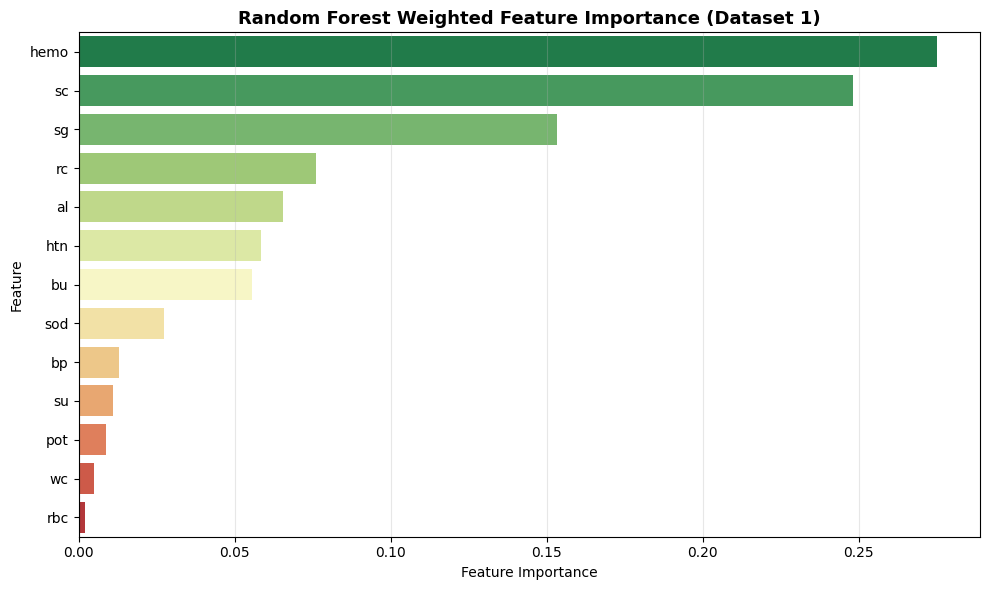

Top 15 Most Important Features:
 1. hemo       0.2752
 2. sc         0.2483
 3. sg         0.1532
 4. rc         0.0763
 5. al         0.0655
 6. htn        0.0585
 7. bu         0.0556
 8. sod        0.0273
 9. bp         0.0131
10. su         0.0110
11. pot        0.0088
12. wc         0.0051
13. rbc        0.0022


In [8]:
plot_encoded_feature_importance(model, numeric_features, 'Random Forest Weighted Feature Importance (Dataset 1)')

### Plot Original Feature Importance

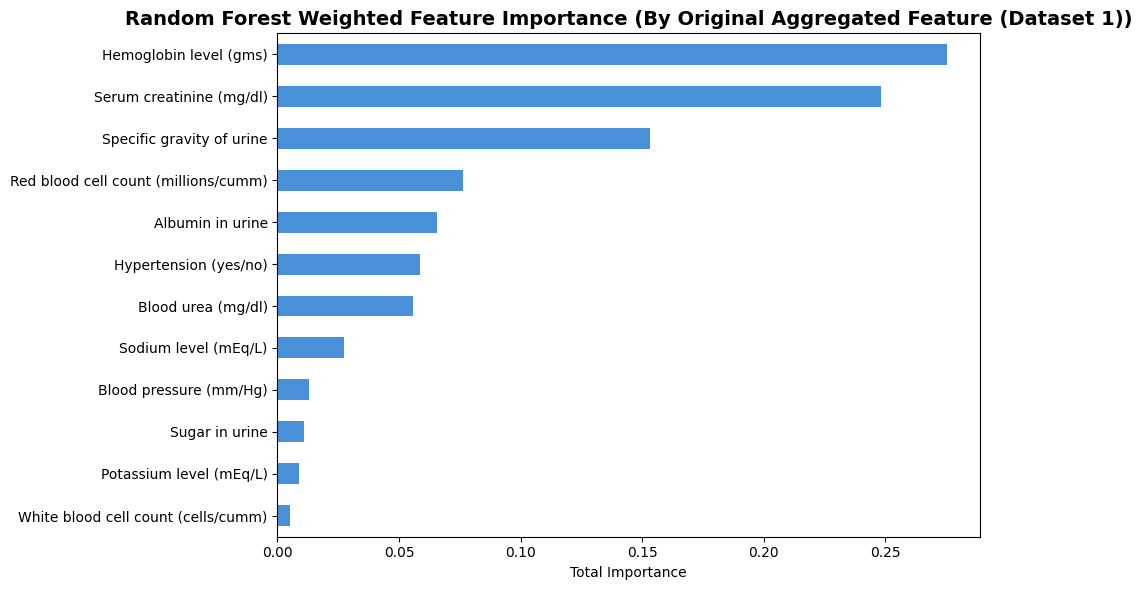

In [9]:
plot_original_feature_importance(model, numeric_features, 'Random Forest Weighted Feature Importance (By Original Aggregated Feature (Dataset 1))')

From the feature importance plot for **Dataset 1**, **Hemoglobin level (gms)** is shown to be the most *influential feature*, followed by **Serum Creatinine (mg/dl)** then **Specific gravity of urine**. 

## Dataset 2 Balanced Random Forest Classifier Model Feature Analysis

### Load Preprocessor and Models

In [10]:
# Load preprocessor and model for dataset 2
preprocessor = joblib.load('../models/dataset_2/preprocessor.joblib')
model = joblib.load('../models/dataset_2/RandomForestClassifier_weighted.joblib')

### Plot Encoded Feature Importance

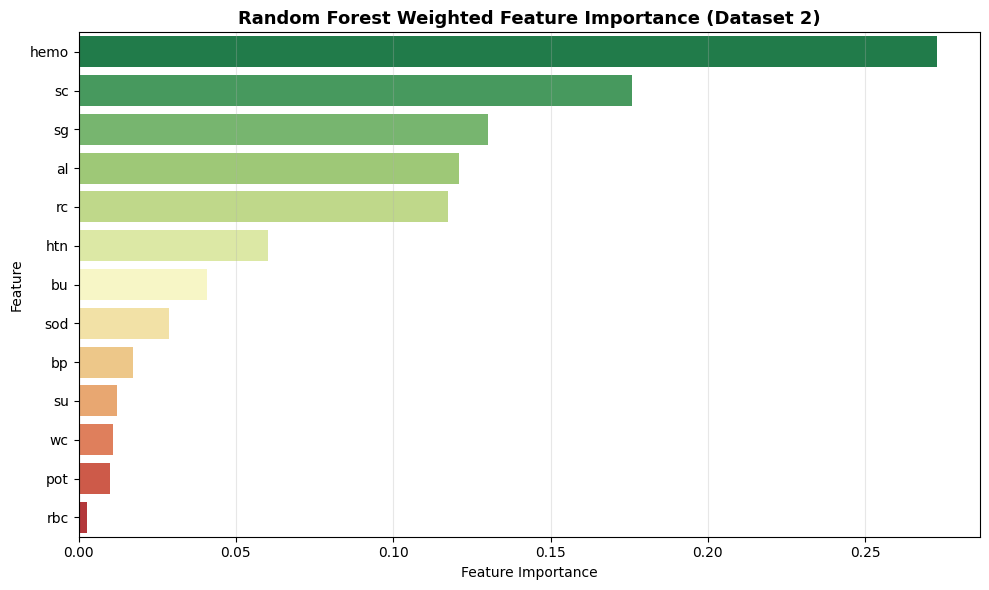

Top 15 Most Important Features:
 1. hemo       0.2728
 2. sc         0.1760
 3. sg         0.1301
 4. al         0.1208
 5. rc         0.1175
 6. htn        0.0604
 7. bu         0.0408
 8. sod        0.0288
 9. bp         0.0172
10. su         0.0121
11. wc         0.0109
12. pot        0.0100
13. rbc        0.0026


In [11]:
plot_encoded_feature_importance(model, numeric_features, 'Random Forest Weighted Feature Importance (Dataset 2)')

### Plot Original Feature Importance

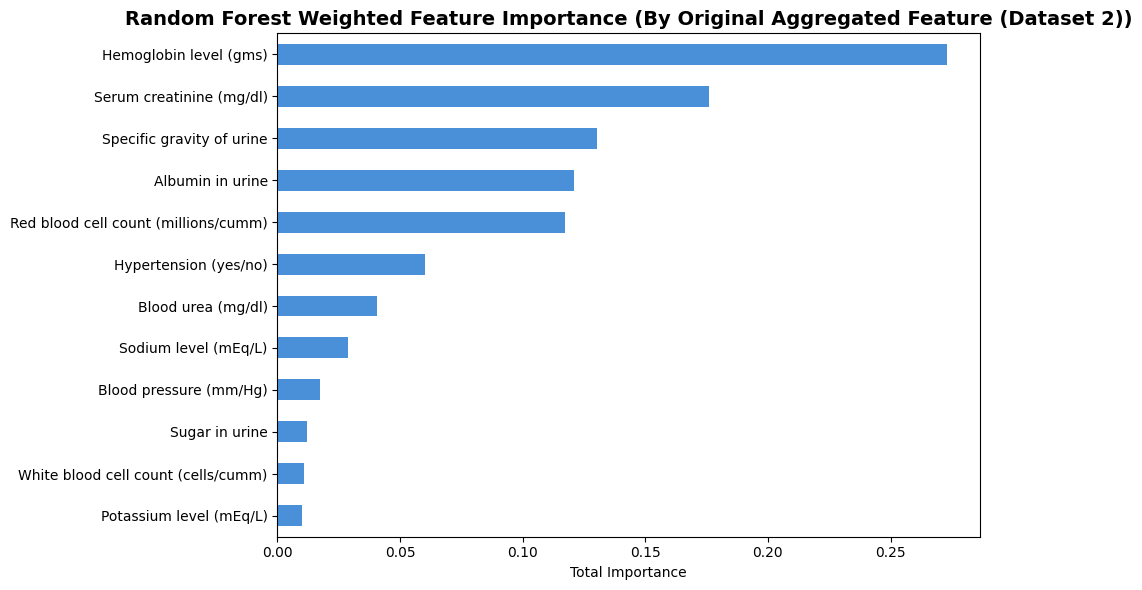

In [12]:
plot_original_feature_importance(model, numeric_features, 'Random Forest Weighted Feature Importance (By Original Aggregated Feature (Dataset 2))')

**Dataset 2** shows the same pattern, with **Hemoglobin**, **Serum Creatinine (mg/dl)**, and **Specific Gravity of urine** again appearing as the top three features in the exact same order of importance. This indicates strong consistency between **Dataset 1** and **Dataset 2** in terms of which clinical features are most predictive of CKD.

## Dataset 3 Balanced Random Forest Classifier Model Feature Analysis

### Load Preprocessor And Models

In [13]:
preprocessor = joblib.load('../models/dataset_3/preprocessor.joblib')
model = joblib.load('../models/dataset_3/RandomForestClassifier_weighted.joblib')

### Plot Encoded Feature Importance

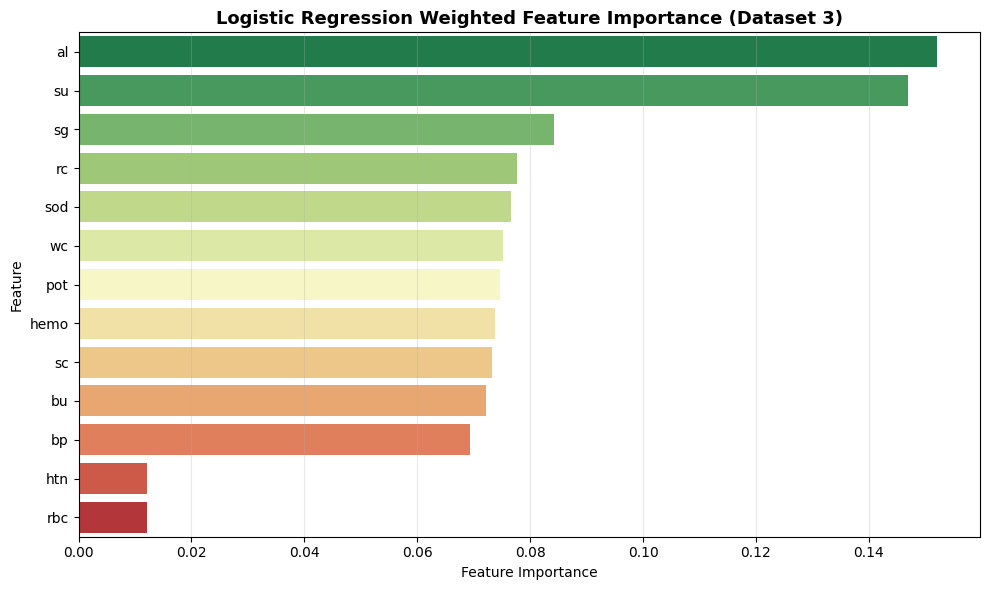

Top 15 Most Important Features:
 1. al         0.1521
 2. su         0.1470
 3. sg         0.0843
 4. rc         0.0776
 5. sod        0.0766
 6. wc         0.0752
 7. pot        0.0746
 8. hemo       0.0737
 9. sc         0.0732
10. bu         0.0721
11. bp         0.0693
12. htn        0.0122
13. rbc        0.0121


In [14]:
plot_encoded_feature_importance(model, numeric_features, 'Logistic Regression Weighted Feature Importance (Dataset 3)')

### Plot Original Feature Importance

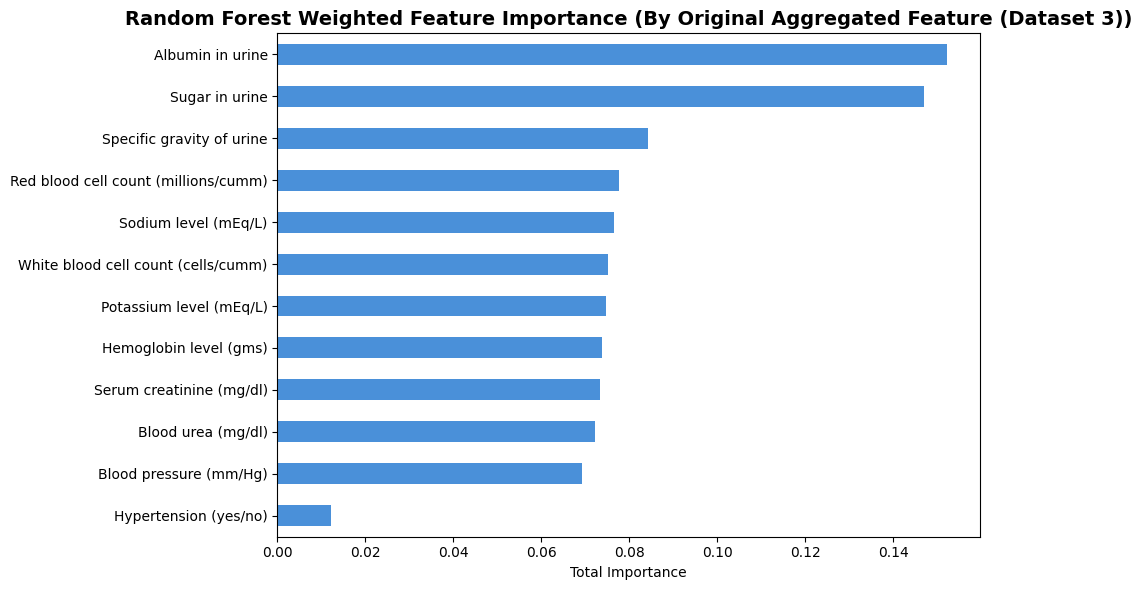

In [15]:
plot_original_feature_importance(model, numeric_features, 'Random Forest Weighted Feature Importance (By Original Aggregated Feature (Dataset 3))')

In contrast, **Dataset 3** shows a different pattern, where **Albumin in urine** and **Sugar in urine** are the most influential features, followed by **Specific Gravity of urine**. While **Specific Gravity** remains important across all datasets, the shift in the top-ranked features suggests that **Dataset 3** captures CKD using different dominant features compared to **Datasets 1** and **2**.